In [15]:
!pip install requests geopy matplotlib

In [16]:
from getpass import getpass
API_KEY = getpass("Enter your OpenWeatherMap API key: ")

Enter your OpenWeatherMap API key: ··········


In [17]:
from geopy.geocoders import Nominatim

city = input("Enter city name: ")

geolocator = Nominatim(user_agent="aqi_analysis_project")
location = geolocator.geocode(city)

if location:
    latitude = location.latitude
    longitude = location.longitude

    print("City:", city)
    print("Latitude:", latitude)
    print("Longitude:", longitude)
else:
    print("City not found.")

Enter city name: delhi
City: delhi
Latitude: 28.6328027
Longitude: 77.2197713


In [18]:
import requests

url = (
    "https://api.openweathermap.org/data/2.5/air_pollution"
    f"?lat={latitude}&lon={longitude}&appid={API_KEY}"
)

response = requests.get(url)

print("Status Code:", response.status_code)

if response.status_code == 200:
    data = response.json()
    print(data)
else:
    print("Unable to fetch air-quality data.")

Status Code: 200
{'coord': {'lon': 77.2198, 'lat': 28.6327}, 'list': [{'main': {'aqi': 2}, 'components': {'co': 331.49, 'no': 0.14, 'no2': 9, 'o3': 42.81, 'so2': 1.39, 'pm2_5': 12.3, 'pm10': 13.86, 'nh3': 0.79}, 'dt': 1789388987}]}


In [19]:
aqi = data["list"][0]["main"]["aqi"]

print("AQI:", aqi)

AQI: 2


In [20]:
categories = {
    1: "Good",
    2: "Fair",
    3: "Moderate",
    4: "Poor",
    5: "Very Poor"
}

category = categories.get(aqi, "Unknown")

print("AQI Category:", category)

AQI Category: Fair


In [21]:
components = data["list"][0]["components"]

print("Pollutant Levels:")

for pollutant, value in components.items():
    print(f"{pollutant}: {value}")

Pollutant Levels:
co: 331.49
no: 0.14
no2: 9
o3: 42.81
so2: 1.39
pm2_5: 12.3
pm10: 13.86
nh3: 0.79


In [22]:
pollutant_names = {
    "co": "Carbon Monoxide (CO)",
    "no": "Nitrogen Monoxide (NO)",
    "no2": "Nitrogen Dioxide (NO₂)",
    "o3": "Ozone (O₃)",
    "so2": "Sulfur Dioxide (SO₂)",
    "pm2_5": "PM2.5",
    "pm10": "PM10",
    "nh3": "Ammonia (NH₃)"
}

print(f"\nAir Quality Report — {city}")
print("-" * 40)

print(f"AQI: {aqi}")
print(f"Category: {category}")

print("\nPollutant Levels:")

for key, value in components.items():
    name = pollutant_names.get(key, key)
    print(f"{name}: {value}")


Air Quality Report — delhi
----------------------------------------
AQI: 2
Category: Fair

Pollutant Levels:
Carbon Monoxide (CO): 331.49
Nitrogen Monoxide (NO): 0.14
Nitrogen Dioxide (NO₂): 9
Ozone (O₃): 42.81
Sulfur Dioxide (SO₂): 1.39
PM2.5: 12.3
PM10: 13.86
Ammonia (NH₃): 0.79


In [23]:
import time
import matplotlib.pyplot as plt

aqi_values = []

print(f"Collecting AQI readings for {city}...\n")

for i in range(5):
    response = requests.get(url)

    if response.status_code == 200:
        reading = response.json()["list"][0]["main"]["aqi"]
        aqi_values.append(reading)

        print(f"Reading {i + 1}: AQI = {reading} ({categories.get(reading,'Unknown')})")

    else:
        print(f"Reading {i + 1}: Failed")

    if i < 4:
        time.sleep(5)


Reading 1: AQI = 2 (Fair)
Reading 2: AQI = 2 (Fair)
Reading 3: AQI = 2 (Fair)
Reading 4: AQI = 2 (Fair)
Reading 5: AQI = 2 (Fair)


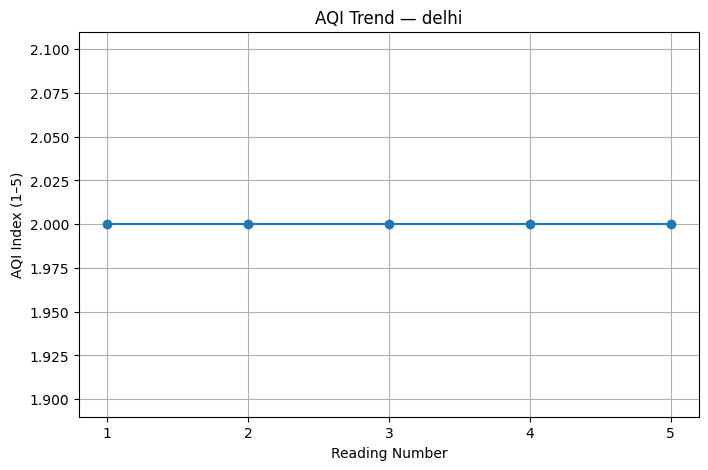

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(aqi_values) + 1),
    aqi_values,
    marker="o"
)

plt.title(f"AQI Trend — {city}")
plt.xlabel("Reading Number")
plt.ylabel("AQI Index (1–5)")

plt.xticks(range(1, len(aqi_values) + 1))

plt.grid(True)

plt.show()

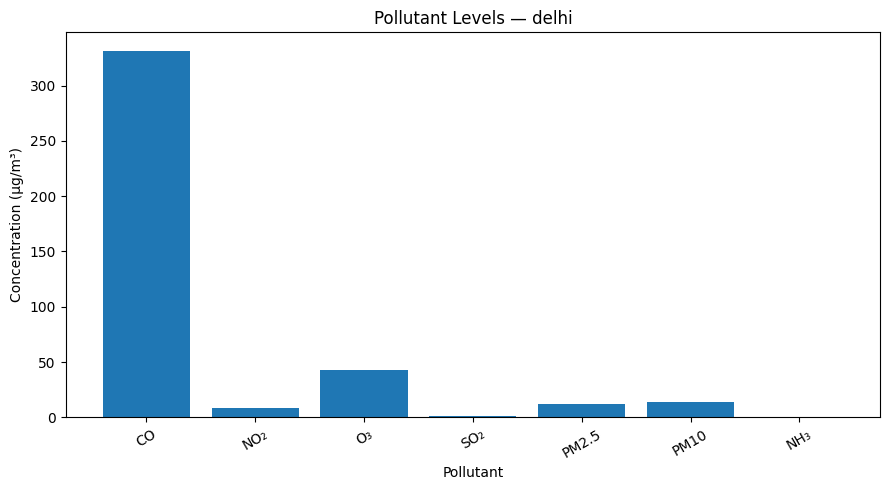

In [25]:
pollutants = {
    "CO": components["co"],
    "NO₂": components["no2"],
    "O₃": components["o3"],
    "SO₂": components["so2"],
    "PM2.5": components["pm2_5"],
    "PM10": components["pm10"],
    "NH₃": components["nh3"]
}

plt.figure(figsize=(9, 5))

plt.bar(pollutants.keys(), pollutants.values())

plt.title(f"Pollutant Levels — {city}")
plt.xlabel("Pollutant")
plt.ylabel("Concentration (μg/m³)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()